# Buổi 7 — Tự tương quan và tính dừng

**Một câu:** ACF và PACF cho biết quá khứ "nói" gì về hiện tại; ADF + KPSS cho biết chuỗi có **dừng** không; sai phân chữa chuỗi
không dừng — nhưng sai phân thừa lại làm hỏng nó.

Tình huống: GDP thực của Mỹ tăng đều từ 1947, lượt thuê xe đạp lặp theo ngày và tuần, và bốn chuỗi mô phỏng từ cùng một dãy nhiễu.
Chuỗi nào dùng được quá khứ để dự báo, chuỗi nào phải biến đổi trước? Sáu phần dưới trả lời.

| Phần | Câu hỏi |
|---|---|
| 1 | Tính ACF tay thế nào, nhận ra ba hình dạng gì? |
| 2 | Trễ 2 có thêm gì sau khi đã biết trễ 1? |
| 3 | Sai số còn mẫu hình không — kiểm bằng một con số? |
| 4 | Dừng là gì; random walk khác dừng quanh xu hướng ra sao? |
| 5 | Hai kiểm định tính dừng đọc thế nào? |
| 6 | Sai phân bao nhiêu lần là đủ? |

## 0. Dữ liệu

**Bộ dữ liệu BEA National Income and Product Accounts — quarterly.** Như bảng tháng của BEA nhưng gom **mọi chuỗi theo quý**, từ 1947. Chuỗi `A191RX` là **GDP thực** của Mỹ (tỷ USD giá
năm 2017, đã điều chỉnh mùa vụ, quy ra mức cả năm).

Nguồn: Source: U.S. Bureau of Economic Analysis, National Income and Product Accounts (truy cập 2026-09-17). Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `%SeriesCode` | mã chuỗi, ví dụ `A191RX` (GDP thực) |
| `Period` | quý, dạng `2024Q1` |
| `Value` | giá trị, có dấu phẩy ngăn nghìn |

**Bộ dữ liệu Federal Reserve G.17 — Industrial Production.** Cục Dự trữ Liên bang Mỹ đo **sản lượng công nghiệp** (nhà máy, mỏ, điện khí) mỗi tháng bằng một chỉ số, **2017 = 100**,
đã điều chỉnh mùa vụ. Tệp CSV có 5 dòng mô tả (đơn vị, mã chuỗi) rồi mới tới bảng, từ 1/2000 tới 12/2024.

Nguồn: Board of Governors of the Federal Reserve System, G.17 Industrial Production and Capacity Utilization (truy cập 2026-09-17). Giấy phép Public domain (Federal Reserve Board).

| Cột | Nghĩa |
|---|---|
| `Series Description / Time Period` | tháng, dạng `2024-03` |
| `Total index; s.a. IP` | chỉ số sản lượng công nghiệp tổng hợp (mã IP.B50001.S) |

**Bộ dữ liệu Bike Sharing.** Nhóm tác giả ở Đại học Porto lấy nhật ký mọi lượt thuê của **Capital Bikeshare** — hệ thống xe đạp công cộng ở
Washington D.C., lấy xe ở trạm này, trả ở trạm khác — trong **hai năm 2011–2012**, đếm số lượt theo từng giờ và từng
ngày, rồi ghép thêm thời tiết và lịch nghỉ lễ. Hai bảng: `hour.csv` mỗi dòng là **một giờ** (17.379 dòng), `day.csv`
mỗi dòng là **một ngày** (731 dòng). Số lượt là của **cả hệ thống**, không phải một trạm.

Nguồn: Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `cnt` | **số lượt thuê** trong giờ (hoặc ngày) đó — thứ cần dự báo; bằng `casual` (khách vãng lai) + `registered` (hội viên) |
| `dteday`, `hr` | ngày, và giờ trong ngày (0–23; `day.csv` không có `hr`) |
| `yr` | năm: 0 là 2011, 1 là 2012 |
| `weekday`, `workingday` | thứ trong tuần (0 = Chủ nhật, 6 = thứ Bảy); ngày làm việc (1) hay nghỉ — cuối tuần, lễ (0) |
| `weathersit` | thời tiết: 1 quang đãng, 2 sương mù/nhiều mây, 3 mưa nhẹ/tuyết nhẹ, 4 mưa to/bão |
| `temp`, `hum` | nhiệt độ và độ ẩm, đã chia cho giá trị lớn nhất (41 °C, 100%) nên nằm trong 0–1 |

Ô dưới tải dữ liệu (36 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [1]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "bea-nipa-quy": ("7fa7dfb39b765e5cebfb0561f1dd9cc97527f96e9d630fadc01083c30044de83", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/bea-nipa-quy/NipaDataQ.txt",
        "https://apps.bea.gov/national/Release/TXT/NipaDataQ.txt",
    ]),
    "frb-g17-san-luong-cong-nghiep": ("3956c6626866f458434ee81dffb72374b4653e0fd183f6286b84a3da33421d15", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/frb-g17-san-luong-cong-nghiep/g17-2000-2024.csv",
        "https://www.federalreserve.gov/datadownload/Output.aspx?rel=G17&series=403cc340ea3a19566b30770b9e4793ab&lastobs=&from=01/01/2000&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn&type=package",
    ]),
    "uci-bike-sharing": ("b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-bike-sharing/bike+sharing+dataset.zip",
        "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

bea-nipa-quy                 /home/tony/.cache/khoa-forecasting/sha256/7f/7fa7dfb39b765e5cebfb0561f1dd9cc97527f96e9d630fadc01083c30044de83
frb-g17-san-luong-cong-nghiep /home/tony/.cache/khoa-forecasting/sha256/39/3956c6626866f458434ee81dffb72374b4653e0fd183f6286b84a3da33421d15
uci-bike-sharing             /home/tony/.cache/khoa-forecasting/sha256/b7/b70182d0d0508e9abbb79306ce5c0cec34869000f8220175ac83d11dbe845401


In [2]:
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

q = pd.read_csv(lay("bea-nipa-quy"), thousands=",")
q = q[q["%SeriesCode"] == "A191RX"]
gdp = pd.Series(q["Value"].astype(float).to_numpy(), index=pd.PeriodIndex(q["Period"], freq="Q").to_timestamp()).sort_index()
g17 = pd.read_csv(lay("frb-g17-san-luong-cong-nghiep"), skiprows=5)
san_luong = pd.Series(g17["IP.B50001.S"].astype(float).to_numpy(), index=pd.to_datetime(g17["Time Period"] + "-01"))
with zipfile.ZipFile(lay("uci-bike-sharing")) as z:
    h = pd.read_csv(z.open("hour.csv"), parse_dates=["dteday"])
luot = pd.Series(h["cnt"].to_numpy(float), index=h["dteday"] + pd.to_timedelta(h["hr"], unit="h")).asfreq("h")   # giờ thiếu → NaN
print(f"GDP: {len(gdp)} quý {gdp.index[0]:%Y}–{gdp.index[-1]:%Y} | sản lượng CN: {len(san_luong)} tháng | lượt thuê: {len(luot):,} giờ")

GDP: 318 quý 1947–2026 | sản lượng CN: 300 tháng | lượt thuê: 17,544 giờ


## 1. ACF tính tay, và ba hình dạng cần nhận ra

**Vấn đề.** Muốn dùng quá khứ để dự báo, trước hết phải biết quá khứ có "nói" gì về hiện tại không, và ở độ trễ nào.

> **nhiễu trắng** · *white noise*
>
> - **Là gì:** chuỗi không có tự tương quan ở trễ nào: quá khứ không giúp đoán tương lai.
> - **Ví dụ:** kết quả tung xúc xắc từng lần: lần trước ra 6 không nói gì về lần sau.
> - **Để làm gì:** là đích của mọi mô hình: sai số dự báo phải là nhiễu trắng, còn mẫu hình là còn thông tin chưa dùng.

**Lý do.** Tự tương quan ở trễ $k$ (đã gặp ở buổi 4) cộng các tích "độ lệch bây giờ × độ lệch $k$ bước trước", chia tổng bình phương
độ lệch của **cả** chuỗi — nên $r_k$ co về 0 ở trễ lớn, nơi ít cặp:

$$r_k = \frac{\sum_{t=k+1}^{T}(y_t-\bar y)(y_{t-k}-\bar y)}{\sum_{t=1}^{T}(y_t-\bar y)^2}$$

Ba hình dạng: **nhiễu trắng** ($r_k$ quanh 0), **xu hướng hoặc random walk** ($r_1$ gần 1, giảm rất chậm), **mùa vụ** (đỉnh ở bội số
chu kỳ).

**Kết quả.**

2,3,5,6,5,3 → r1, r2 = [ 0.333 -0.417] | statsmodels: [ 0.333 -0.417]


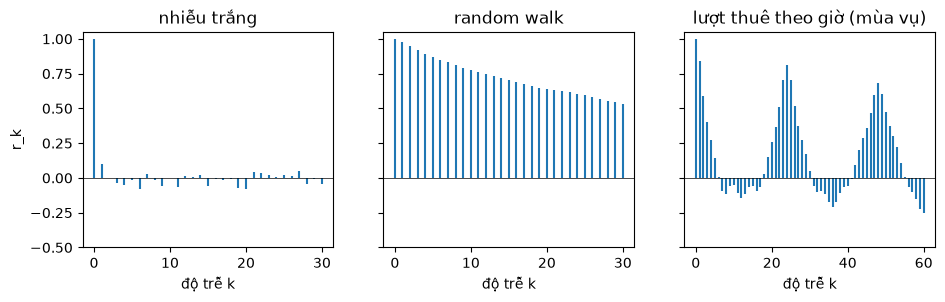

In [3]:
def acf_tu_viet(y, so_tre):
    y = np.asarray(y, dtype=float)
    lech = y - np.nanmean(y)
    mau = np.nansum(lech**2)
    return np.array([1.0] + [np.nansum(lech[k:] * lech[:-k]) / mau for k in range(1, so_tre + 1)])


print("2,3,5,6,5,3 → r1, r2 =", acf_tu_viet([2, 3, 5, 6, 5, 3], 2)[1:].round(3),
      "| statsmodels:", acf([2, 3, 5, 6, 5, 3], nlags=2, adjusted=False)[1:].round(3))

e = np.random.default_rng(42).normal(size=500)
ba = {"nhiễu trắng": e, "random walk": e.cumsum(), "lượt thuê theo giờ (mùa vụ)": luot.to_numpy()}
fig, truc = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for ax, (ten, y) in zip(truc, ba.items(), strict=True):
    so_tre = 60 if "lượt" in ten else 30
    ax.vlines(range(so_tre + 1), 0, acf_tu_viet(y, so_tre))
    ax.axhline(0, color="k", lw=0.5)
    ax.set(title=ten, xlabel="độ trễ k", ylim=(-0.5, 1.05))
truc[0].set_ylabel("r_k")
plt.show()

$r_1$ = 0,333 và $r_2$ = −0,417 như tính tay (các số liền nhau hay cùng phía trung bình, cách hai bước thì hay ở hai phía). Ba ô là ba
hình dạng: quanh 0; giảm rất chậm; đỉnh ở trễ 24, 48.

**Bài học.** ACF quanh 0 là nhiễu trắng, giảm rất chậm là chưa dừng, có đỉnh đều là mùa vụ.

## 2. PACF: trễ 2 còn thêm gì sau khi đã biết trễ 1

**Vấn đề.** Với AR(1), hôm nay chỉ phụ thuộc trực tiếp vào hôm qua; nhưng hôm qua phụ thuộc hôm kia, nên ACF trễ 2 vẫn lớn. Trễ 2 có
thêm thông tin **riêng** không?

> **PACF** · *partial autocorrelation function*
>
> - **Là gì:** tự tương quan riêng phần: tương quan giữa $y_t$ và $y_{t-k}$ **sau khi** bỏ phần đã giải thích được bằng các trễ ngắn hơn. Ở trễ 2: $\phi_{22} = (r_2 - r_1^2) / (1 - r_1^2)$.
> - **Ví dụ:** AR(1) với $\phi$ = 0,7: $r_2$ = 0,49 nhưng PACF trễ 2 = (0,49 − 0,49) / (1 − 0,49) = 0.
> - **Để làm gì:** chỉ ra mô hình cần những trễ nào — AR(1) thì PACF cắt sau trễ 1.
>
> 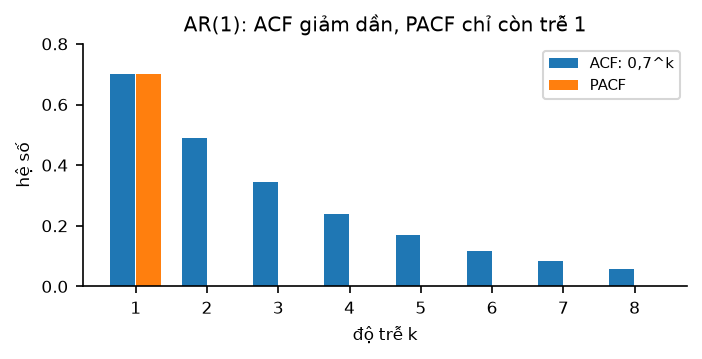

**Lý do.** Tin đồn A → B → C: C giống A chỉ vì cùng nối qua B; biết B rồi thì A không thêm gì. PACF đo phần "thêm" đó. Chuỗi có
$r_1$ = 0,5, $r_2$ = 0,4 cho PACF(2) = (0,4 − 0,25) / (1 − 0,25) = 0,2: trễ 2 có thông tin riêng.

**Kết quả.** Bốn chuỗi mô phỏng dùng **chung** một dãy nhiễu (seed 42, 500 điểm):

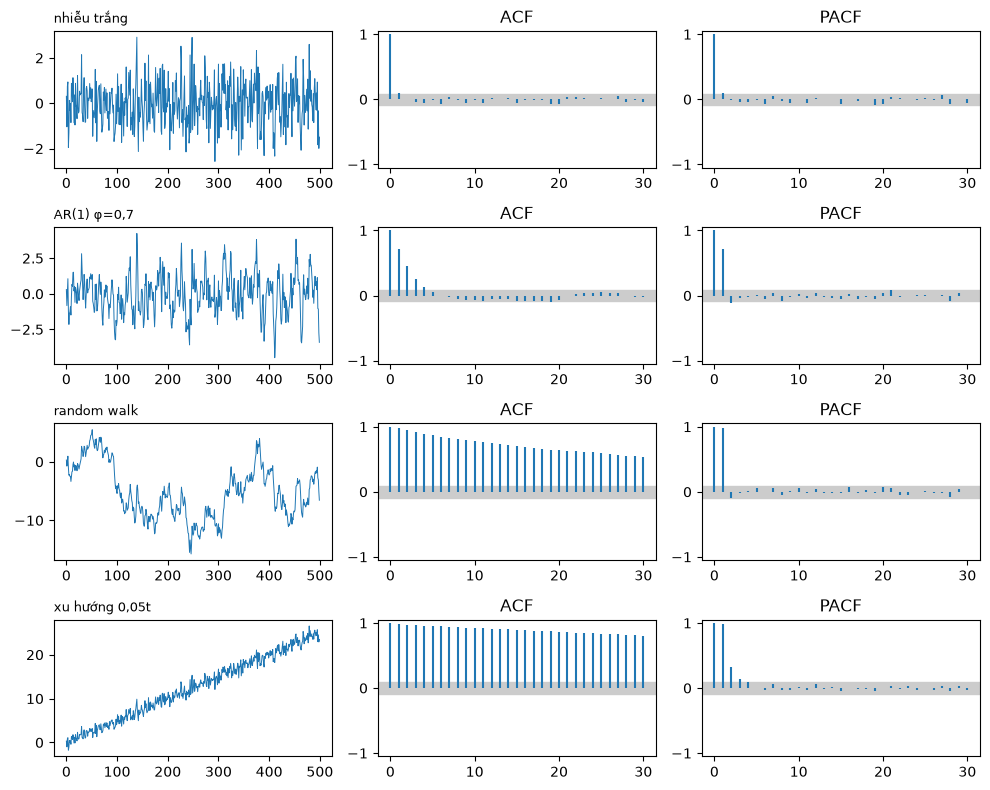

                   r1    r30  PACF1  PACF2
nhiễu trắng     0.099 -0.047  0.099 -0.009
AR(1) φ=0,7     0.713 -0.026  0.713 -0.110
random walk     0.976  0.530  0.976 -0.091
xu hướng 0,05t  0.979  0.806  0.979  0.320


In [4]:
ar = np.empty(500)
ar[0] = e[0]
for t in range(1, 500):
    ar[t] = 0.7 * ar[t - 1] + e[t]
bon = {"nhiễu trắng": e, "AR(1) φ=0,7": ar, "random walk": e.cumsum(), "xu hướng 0,05t": 0.05 * np.arange(500) + e}
DAI = 1.96 / np.sqrt(500)                       # dải ±1,96/√T

fig, truc = plt.subplots(4, 3, figsize=(10, 8))
bang = {}
for hang, (ten, y) in enumerate(bon.items()):
    r, p = acf_tu_viet(y, 30), pacf(y, nlags=30, method="ywm")      # khai method rõ: pacf() mặc định khác plot_pacf()
    truc[hang, 0].plot(y, lw=0.7)
    truc[hang, 0].set_title(ten, loc="left", fontsize=9)
    for ax, v, ten_o in ((truc[hang, 1], r, "ACF"), (truc[hang, 2], p, "PACF")):
        ax.vlines(range(31), 0, v)
        ax.axhspan(-DAI, DAI, color="0.8")
        ax.set(ylim=(-1.05, 1.05), title=ten_o)
    bang[ten] = {"r1": r[1], "r30": r[30], "PACF1": p[1], "PACF2": p[2]}
fig.tight_layout()
plt.show()
print(pd.DataFrame(bang).T.round(3))

AR(1): ACF giảm nhanh, PACF cắt sau trễ 1. Random walk và xu hướng có ACF giảm rất chậm, $r_1$ đều gần 0,98 và $r_{30}$ còn lớn — chỉ
nhìn ACF **không phân biệt được** hai loại này, mà chúng cần chữa khác nhau (phần 4).

**Bài học.** PACF trễ $k$ là phần tương quan còn lại sau khi bỏ những gì các trễ ngắn hơn đã giải thích.

## 3. Đừng đếm cột vượt dải; dùng Ljung-Box

**Vấn đề.** Sau khi dự báo, sai số còn mẫu hình không? Nhìn 20 cột ACF rồi đếm cột vượt dải rất dễ tự lừa mình.

> **Ljung-Box** · *Ljung-Box test*
>
> - **Là gì:** kiểm định gộp nhiều $r_k$ thành một con số $Q^* = T(T+2)\sum_{k=1}^{\ell} r_k^2/(T-k)$ để hỏi "đây có phải nhiễu trắng không". $H_0$: nhiễu trắng.
> - **Ví dụ:** 100 điểm, $r_1$ = 0,2, $r_2$ = 0,1: $Q^*$ ≈ 5,16 < ngưỡng 5,99 → chưa đủ bằng chứng có tự tương quan.
> - **Để làm gì:** kiểm sai số dự báo còn mẫu hình không, thay cho việc đếm cột vượt dải.
>
> 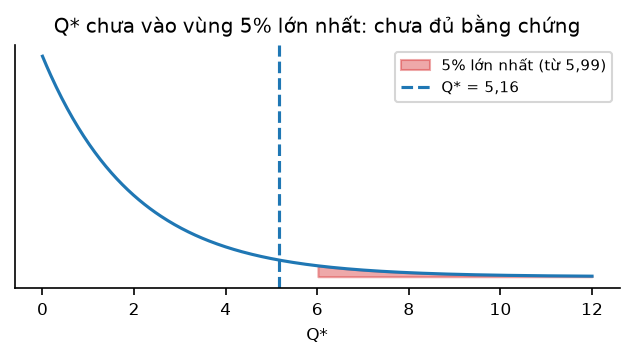

> **bậc tự do** · *degrees of freedom*
>
> - **Là gì:** số "mảnh thông tin độc lập" mà kiểm định dùng; ở Ljung-Box là số trễ trừ số tham số đã ước lượng.
> - **Ví dụ:** 10 trễ trên sai số của mô hình 2 tham số → 8 bậc tự do, ngưỡng 5% là 15,51 thay vì 18,31.
> - **Để làm gì:** quên trừ thì p-value cao giả — dễ kết luận "sai số là nhiễu trắng" khi chưa phải.

**Lý do.** Mỗi cột có 5% khả năng vượt dải dù chuỗi là nhiễu thuần; 20 cột thì trung bình 1 cột vượt. Ljung-Box cộng bình phương các
$r_k$ thành một con số; nếu chuỗi là nhiễu trắng, $Q^*$ có phân phối $\chi^2$ (khi bình phương — tổng bình phương của vài số ngẫu
nhiên hình chuông) với số bậc tự do bằng số trễ. Chỉ cần tra ngưỡng: 2 bậc tự do 5,99; 8 bậc 15,51; 10 bậc 18,31.

**Kết quả.** 1.000 chuỗi nhiễu trắng (seed 2026), rồi ví dụ tay:

In [5]:
rng = np.random.default_rng(2026)
dem = np.array([np.sum(np.abs(acf_tu_viet(rng.normal(size=500), 20)[1:]) > DAI) for _ in range(1000)])
print(f"số cột vượt dải trong 20 trễ: trung bình {dem.mean():.2f}; {np.mean(dem >= 1):.0%} số chuỗi có ít nhất 1 cột")

T, r = 100, np.array([0.2, 0.1])
Q = T * (T + 2) * np.sum(r**2 / (T - np.arange(1, 3)))
print(f"ví dụ tay: Q* = {Q:.2f}, ngưỡng 5% (2 bậc tự do) = {stats.chi2.ppf(0.95, 2):.2f}, p = {stats.chi2.sf(Q, 2):.3f}")

for s in (1, 2, 3):
    nhieu = np.random.default_rng(s).normal(size=500)
    p0 = acorr_ljungbox(nhieu, lags=[10])["lb_pvalue"].iloc[0]
    p2 = acorr_ljungbox(nhieu, lags=[10], model_df=2)["lb_pvalue"].iloc[0]
    print(f"nhiễu trắng seed {s}: Ljung-Box 10 trễ p = {p0:.3f} | nếu là sai số mô hình 2 tham số (model_df=2): p = {p2:.3f}")

số cột vượt dải trong 20 trễ: trung bình 0.95; 62% số chuỗi có ít nhất 1 cột
ví dụ tay: Q* = 5.16, ngưỡng 5% (2 bậc tự do) = 5.99, p = 0.076
nhiễu trắng seed 1: Ljung-Box 10 trễ p = 0.081 | nếu là sai số mô hình 2 tham số (model_df=2): p = 0.033
nhiễu trắng seed 2: Ljung-Box 10 trễ p = 0.796 | nếu là sai số mô hình 2 tham số (model_df=2): p = 0.623
nhiễu trắng seed 3: Ljung-Box 10 trễ p = 0.885 | nếu là sai số mô hình 2 tham số (model_df=2): p = 0.747


Nhiễu trắng thuần mà trung bình vẫn có 0,95 cột vượt dải, và 62% số chuỗi có ít nhất một cột vượt. Ljung-Box trên ba chuỗi nhiễu
cho p từ 0,081 tới 0,885: không bác bỏ, đúng như mong đợi. Khai `model_df=2` làm p **nhỏ** đi — kiểm định chặt hơn, không dễ dãi hơn.

**Bài học.** Một cột vượt dải không phải bằng chứng. Gộp bằng Ljung-Box (FPP: 10 trễ cho dữ liệu không mùa vụ, $2m$ cho dữ liệu mùa vụ,
không quá $T/5$), và nhớ `model_df` khi kiểm sai số của mô hình.

## 4. Random walk và dừng quanh xu hướng trông giống nhau nhưng chữa khác nhau

**Vấn đề.** Chuỗi không dừng thì cần biến đổi. Nhưng có hai loại không dừng hay gặp, và chữa nhầm thuốc thì hỏng.

> **dừng** · *stationary*
>
> - **Là gì:** tính chất thống kê — mức trung bình, độ dao động, tự tương quan — không đổi theo thời điểm quan sát.
> - **Ví dụ:** nhiệt độ phòng có máy lạnh đặt 25 °C: lúc 24,5, lúc 25,8, nhưng luôn bị kéo về 25.
> - **Để làm gì:** chỉ khi chuỗi dừng, những gì học từ quá khứ mới áp được cho tương lai; nhiều mô hình (ARIMA) giả định điều này.
>
> 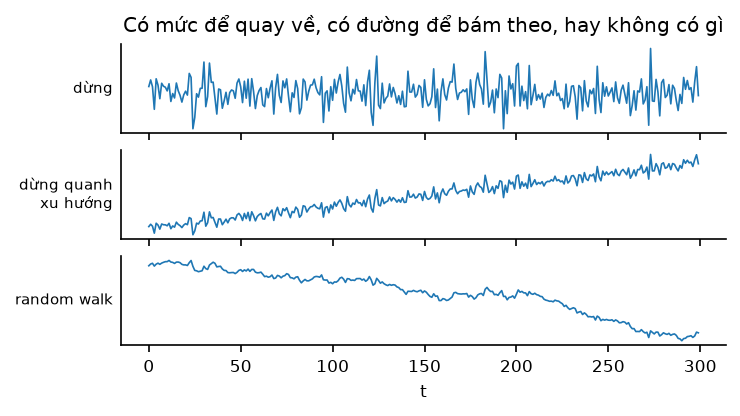

> **random walk**
>
> - **Là gì:** bước ngẫu nhiên: giá trị mới = giá trị cũ + một bước ngẫu nhiên, $y_t = y_{t-1} + \varepsilon_t$; không có mức để quay về.
> - **Ví dụ:** tung đồng xu, ngửa bước tới, sấp lùi: +1, −1, +1, +1, −1, +1 → vị trí 1, 0, 1, 2, 1, 2.
> - **Để làm gì:** dự báo tốt nhất là giá trị cuối (naive); mọi "xu hướng" thấy trên nó chỉ là tổng dồn của bước ngẫu nhiên.
>
> 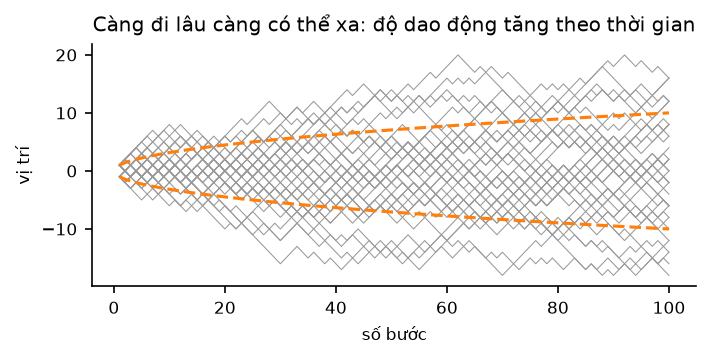

> **dừng quanh xu hướng** · *trend-stationary*
>
> - **Là gì:** chuỗi = một đường xu hướng cố định + dao động dừng quanh nó.
> - **Ví dụ:** chiều cao đứa trẻ tăng đều theo tuổi, dao động nhỏ quanh đường tăng; mô phỏng: 0,05 × t + nhiễu.
> - **Để làm gì:** chữa bằng khử xu hướng (trừ đường thẳng), không phải sai phân.

**Lý do.** Random walk có độ dao động **tăng theo thời gian** (theo căn bậc hai số bước), chữa bằng **sai phân** $y_t - y_{t-1}$ — ra lại
chính nhiễu. Chuỗi dừng quanh xu hướng chữa bằng **khử xu hướng** — trừ đường thẳng khớp nhất theo $t$.

**Kết quả.** 10.000 người tung đồng xu (seed 7), rồi thử cả hai thuốc trên cả hai bệnh:

In [6]:
vi_tri = np.random.default_rng(7).choice([-1, 1], size=(10_000, 100)).cumsum(axis=1)
print("độ lệch chuẩn vị trí sau 4, 25, 100 bước:", vi_tri[:, [3, 24, 99]].std(axis=0).round(1))

t = np.arange(500)
for ten in ["random walk", "xu hướng 0,05t"]:
    y = bon[ten]
    khu_xh = y - np.polyval(np.polyfit(t, y, 1), t)
    sai_phan = np.diff(y)
    print(f"{ten:<15} khử xu hướng → r1 của phần còn lại {acf_tu_viet(khu_xh, 1)[1]:+.3f} | "
          f"sai phân → r1 {acf_tu_viet(sai_phan, 1)[1]:+.3f}")

độ lệch chuẩn vị trí sau 4, 25, 100 bước: [ 2.   5.  10.1]
random walk     khử xu hướng → r1 của phần còn lại +0.975 | sai phân → r1 +0.100
xu hướng 0,05t  khử xu hướng → r1 của phần còn lại +0.099 | sai phân → r1 -0.447


Số bước gấp 25 lần (4 → 100) thì độ lệch chuẩn gấp 5 lần (2,0 → 10,1): độ dao động đổi theo thời gian nên random walk không dừng.
Khử xu hướng một random walk: phần còn lại vẫn lang thang ($r_1$ còn rất lớn). Sai phân chuỗi dừng quanh xu hướng: ra $r_1$ âm rõ —
dấu hiệu sai phân thừa (phần 6). Mỗi bệnh một thuốc.

**Bài học.** Dừng = mức, độ dao động, tự tương quan không đổi theo thời gian. Chuỗi có chu kỳ độ dài không cố định vẫn có thể dừng.
Phân biệt hai loại không dừng phải dùng kiểm định (phần 5), vì ACF của chúng gần như giống hệt.

## 5. ADF và KPSS: chạy cả hai, cùng dạng, đọc bảng 2 × 2

**Vấn đề.** Cần một con số để quyết định "có thành phần random walk không". Hai kiểm định phổ biến đặt câu hỏi theo hai chiều ngược nhau.

> **nghiệm đơn vị** · *unit root*
>
> - **Là gì:** tên kỹ thuật của "có thành phần random walk": viết $y_t = \rho\, y_{t-1} + \varepsilon_t$, nếu $\rho$ = 1 thì chuỗi có nghiệm đơn vị; $|\rho| < 1$ thì mỗi bước kéo chuỗi một phần về trung bình.
> - **Ví dụ:** trung bình 0, đang ở 10: $\rho$ = 0,7 thì kỳ vọng các bước sau 7 rồi 4,9; $\rho$ = 1 thì mãi là 10.
> - **Để làm gì:** là thứ ADF và KPSS kiểm; có nghiệm đơn vị thì cần sai phân.

> **ADF, KPSS** · *Augmented Dickey-Fuller, Kwiatkowski-Phillips-Schmidt-Shin tests*
>
> - **Là gì:** hai kiểm định tính dừng với $H_0$ ngược nhau. ADF: $H_0$ "có nghiệm đơn vị (không dừng)", p nhỏ = bằng chứng dừng. KPSS: $H_0$ "dừng", p nhỏ = bằng chứng không dừng.
> - **Ví dụ:** chuỗi A 5, 8, 4, 6, 5: cứ cao hơn 5 là bước sau đi xuống (bị kéo về) — ADF tìm đúng lực kéo đó.
> - **Để làm gì:** chạy cả hai rồi đọc bảng 2 × 2 để quyết định có sai phân không.
>
> 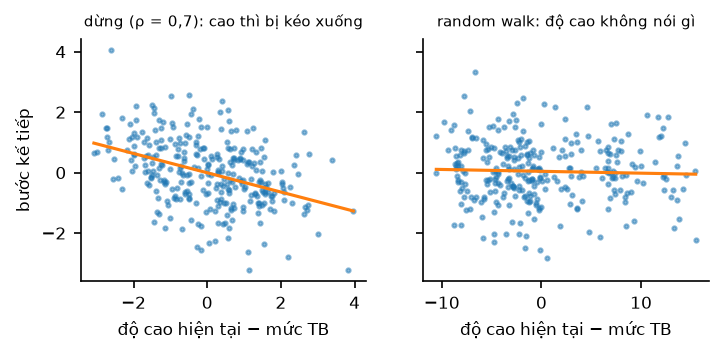

**Lý do.** Cả hai phải khai **dạng**: "c" hỏi "dừng quanh một mức", "ct" hỏi "dừng quanh một đường thẳng". Đọc kết hợp:

| | KPSS không bác bỏ | KPSS bác bỏ |
|---|---|---|
| **ADF bác bỏ** | **dừng** | **mâu thuẫn** — xem lại chuỗi (độ dao động đổi, cú sốc) |
| **ADF không bác bỏ** | **không đủ bằng chứng** — dữ liệu ngắn hoặc rất gần random walk | **không dừng** → sai phân |

p-value của KPSS bị cắt ở 0,01 và 0,1: "p = 0,10" nghĩa là "p ≥ 0,1".

**Kết quả.**

In [7]:
def kiem_dinh(y, dang="c"):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                   # InterpolationWarning: p của KPSS ngoài bảng tra
        return (adfuller(y, regression=dang, autolag="AIC", result_object=True).pvalue,
                kpss(y, regression=dang, nlags="auto", result_object=True).pvalue)


def o_bang(p_adf, p_kpss):
    return {(True, False): "dừng", (False, True): "không dừng", (True, True): "mâu thuẫn",
            (False, False): "không đủ bằng chứng"}[(p_adf < 0.05, p_kpss < 0.05)]


for ten, y in bon.items():
    kq = {d: kiem_dinh(y, d) for d in ("c", "ct")}
    print(f"{ten:<15} " + " | ".join(f"{d}: ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)}" for d, (a, k) in kq.items()))

tang = np.log(gdp).diff().dropna() * 100                 # % tăng mỗi quý (log 1,01 ≈ 0,01)
for ten, s in [("tăng trưởng GDP 1947–2026", tang), ("tăng trưởng GDP 1985–2019", tang["1985":"2019"])]:
    a, k = kiem_dinh(s)
    print(f"{ten}: {len(s)} quý, ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)}")
a, k = kiem_dinh(np.log(san_luong), "ct")
print(f"log sản lượng công nghiệp, dạng ct: ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)}")

nhiễu trắng     c: ADF 0.000, KPSS 0.100 → dừng | ct: ADF 0.000, KPSS 0.100 → dừng
AR(1) φ=0,7     c: ADF 0.000, KPSS 0.100 → dừng | ct: ADF 0.000, KPSS 0.100 → dừng
random walk     c: ADF 0.073, KPSS 0.010 → không dừng | ct: ADF 0.214, KPSS 0.010 → không dừng
xu hướng 0,05t  c: ADF 0.906, KPSS 0.010 → không dừng | ct: ADF 0.000, KPSS 0.100 → dừng
tăng trưởng GDP 1947–2026: 317 quý, ADF 0.000, KPSS 0.048 → mâu thuẫn
tăng trưởng GDP 1985–2019: 140 quý, ADF 0.000, KPSS 0.099 → dừng
log sản lượng công nghiệp, dạng ct: ADF 0.251, KPSS 0.100 → không đủ bằng chứng


Xu hướng 0,05t: dạng "c" nói không dừng, chỉ dạng "ct" mới lộ đúng **dừng quanh xu hướng**. Random walk có ADF p = 0,073 — dùng mức 10%
sẽ gọi nhầm là dừng; KPSS bắt được. Tăng trưởng GDP cả giai đoạn rơi vào ô mâu thuẫn; bỏ những năm dao động mạnh trước 1985 và cú sốc
đại dịch thì hai kiểm định đồng ý "dừng" — KPSS bác bỏ vì độ dao động đổi theo thời gian, không phải vì random walk. Sản lượng công
nghiệp dạng "ct" là ví dụ ô "không đủ bằng chứng".

**Bài học.** Không bác bỏ không phải chứng minh: chuỗi dừng mà rất gần random walk thì ADF hay bỏ sót. Kiểm định là bằng chứng, không
phải phán quyết.

## 6. Sai phân tới khi KPSS thôi bác bỏ — nhưng dừng tay khi thấy dấu hiệu thừa

**Vấn đề.** Sai phân chữa random walk, nhưng sai phân thêm một chuỗi đã dừng lại làm hỏng nó.

> **sai phân, sai phân mùa vụ** · *differencing, seasonal differencing*
>
> - **Là gì:** thay mỗi giá trị bằng hiệu với giá trị trước ($y_t - y_{t-1}$), hoặc với cùng vị trí của vòng trước ($y_t - y_{t-m}$).
> - **Ví dụ:** 100, 103, 105 → 3, 2. Lượt thuê theo giờ: lượt 8h thứ Hai trừ lượt 8h thứ Hai tuần trước ($m$ = 168).
> - **Để làm gì:** biến chuỗi không dừng thành dừng: sai phân bỏ random walk, sai phân mùa vụ bỏ mùa vụ.

> **sai phân thừa** · *overdifferencing*
>
> - **Là gì:** sai phân một chuỗi đã dừng: thêm nhiễu, tạo tương quan âm giả.
> - **Ví dụ:** 2, −1, 0, 1, −2, 0 (độ lệch chuẩn 1,41) → −3, 1, 1, −3, 2 (độ lệch chuẩn 2,41, $r_1$ ≈ −0,5).
> - **Để làm gì:** biết khi nào dừng tay: $r_1$ về gần −0,5 hoặc độ lệch chuẩn tăng là đã sai phân quá tay.

**Lý do.** Mỗi số gốc xuất hiện hai lần với hai dấu ngược nhau (trong $y_t - y_{t-1}$ và $y_{t+1} - y_t$), nên sai phân chuỗi đã dừng
tạo tương quan âm và thêm nhiễu. Hai dấu hiệu thừa: $r_1$ **gần −0,5**, và **độ lệch chuẩn tăng**. Chuỗi có mùa vụ thì sai phân
**mùa vụ** trước.

**Kết quả.**

In [8]:
def dau_hieu(y):
    y = pd.Series(np.asarray(y, dtype=float)).dropna()
    sp = y.diff().dropna()
    return f"r1 sau sai phân {acf_tu_viet(sp, 1)[1]:+.3f} | độ lệch chuẩn {y.std(ddof=1):.3f} → {sp.std(ddof=1):.3f}"


print("ví dụ tay 2,−1,0,1,−2,0:", dau_hieu([2, -1, 0, 1, -2, 0]))
print("nhiễu trắng (đã dừng):  ", dau_hieu(bon["nhiễu trắng"]))
print("random walk:            ", dau_hieu(bon["random walk"]))

g = np.log1p(luot.interpolate(limit=3))                 # log(1 + y) vì có giờ 0 lượt
bang_sp = {}
for ten, s in [("log", g), ("sai phân thường", g.diff()), ("sai phân mùa vụ 168", g.diff(168)), ("168 rồi thường", g.diff(168).diff())]:
    r = acf_tu_viet(s.to_numpy(), 168)
    bang_sp[ten] = {"r1": r[1], "r24": r[24], "r168": r[168], "độ lệch chuẩn": s.std(ddof=1)}
print(pd.DataFrame(bang_sp).T.round(3))

ví dụ tay 2,−1,0,1,−2,0: r1 sau sai phân -0.498 | độ lệch chuẩn 1.414 → 2.408
nhiễu trắng (đã dừng):   r1 sau sai phân -0.447 | độ lệch chuẩn 0.960 → 1.288
random walk:             r1 sau sai phân +0.100 | độ lệch chuẩn 4.550 → 0.961
                        r1    r24   r168  độ lệch chuẩn
log                  0.898  0.863  0.896          1.430
sai phân thường      0.493  0.676  0.767          0.643
sai phân mùa vụ 168  0.732  0.161 -0.465          0.589
168 rồi thường      -0.249  0.028 -0.498          0.427


Sai phân nhiễu trắng: $r_1$ = −0,447 và độ lệch chuẩn tăng 0,96 → 1,29 (thừa); sai phân random walk: độ lệch chuẩn giảm 4,55 → 0,96
(đúng liều). Với lượt thuê, chỉ sai phân thường thì $r_{24}$, $r_{168}$ còn lớn; sai phân mùa vụ 168 bỏ được mùa vụ; thêm sai phân thường
làm độ lệch chuẩn giảm tiếp (0,589 → 0,427) và $r_1$ chưa tới dấu hiệu thừa — cả hai lần đều đáng. GDP thật:

ACF log GDP trễ 1, 8: [0.991 0.923]
log GDP dạng ct: ADF 0.833, KPSS 0.010 → không dừng
sai phân lần 2 (của % tăng): r1 sau sai phân -0.488 | độ lệch chuẩn 1.105 → 1.455


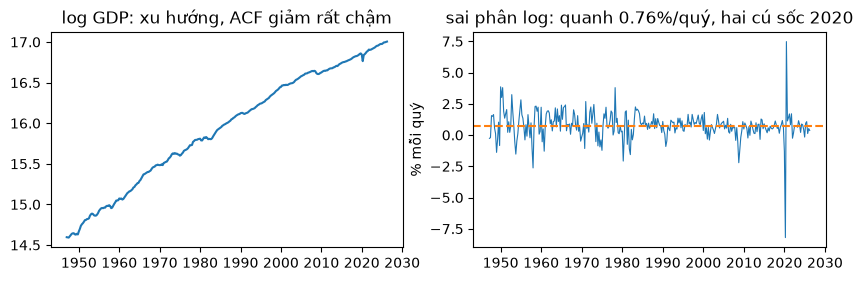

In [9]:
lg = np.log(gdp)
print("ACF log GDP trễ 1, 8:", acf_tu_viet(lg, 8)[[1, 8]].round(3))
a, k = kiem_dinh(lg, "ct")
print(f"log GDP dạng ct: ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)}")
print("sai phân lần 2 (của % tăng):", dau_hieu(tang))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 2.8))
a1.plot(lg)
a1.set(title="log GDP: xu hướng, ACF giảm rất chậm")
a2.plot(tang, lw=0.8)
a2.axhline(tang.mean(), color="tab:orange", ls="--")
a2.set(title=f"sai phân log: quanh {tang.mean():.2f}%/quý, hai cú sốc 2020", ylabel="% mỗi quý")
plt.show()

log GDP chưa dừng; sai phân một lần ra tăng trưởng. Máy móc theo KPSS thì sai phân lần hai (vì ô mâu thuẫn ở phần 5), nhưng lần hai
cho $r_1$ = −0,488 và độ lệch chuẩn tăng 1,105 → 1,455 — đúng hai dấu hiệu thừa. Dừng ở một lần.

**Bài học.** Số lần sai phân tốt thường là số lần cho độ lệch chuẩn **nhỏ nhất**. p-value đẹp không bù được một chuỗi nhiễu hơn.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Lượt thuê theo ngày** (lưới ngày liên tục, nội suy 3 ngày dưới 12 giờ):

In [10]:
ngay = luot.resample("D").sum(min_count=12).interpolate()
a, k = kiem_dinh(ngay)
print(f"{len(ngay)} ngày | ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)} | r1 {acf_tu_viet(ngay, 7)[1]:.3f}, r7 {acf_tu_viet(ngay, 7)[7]:.3f}")
for ten, s in [("gốc", ngay), ("sai phân mùa vụ 7", ngay.diff(7)), ("sai phân thường", ngay.diff()), ("7 rồi thường", ngay.diff(7).diff())]:
    print(f"  {ten:<18} độ lệch chuẩn {s.std(ddof=1):7.1f} | r1 {acf_tu_viet(s.to_numpy(), 1)[1]:+.3f}")

731 ngày | ADF 0.370, KPSS 0.010 → không dừng | r1 0.852, r7 0.760
  gốc                độ lệch chuẩn  1925.0 | r1 +0.852
  sai phân mùa vụ 7  độ lệch chuẩn  1273.4 | r1 +0.327
  sai phân thường    độ lệch chuẩn  1038.7 | r1 -0.329
  7 rồi thường       độ lệch chuẩn  1476.4 | r1 -0.381


Theo ngày, chuỗi không dừng (ADF 0,370, KPSS 0,01). Sai phân thường cho độ lệch chuẩn nhỏ nhất (1.039 lượt); thêm sai phân 7 làm
tăng lại (1.476) và đẩy $r_1$ xuống −0,38 — thừa. Mùa vụ tuần theo **ngày** yếu
vì tổng ngày các thứ chỉ chênh vài phần trăm (buổi 4): nhịp tuần của lượt thuê nằm ở hình dạng **trong** ngày, gộp theo ngày là mất.

**Bài 2 — Độ mạnh của ADF.** 300 chuỗi AR(1) dài 200 điểm mỗi $\phi$ (seed 0):

In [11]:
rng = np.random.default_rng(0)
for phi in (0.7, 0.95):
    bac_bo = 0
    for _ in range(300):
        nhieu = rng.normal(size=200)
        y = np.empty(200)
        y[0] = nhieu[0]
        for t in range(1, 200):
            y[t] = phi * y[t - 1] + nhieu[t]
        bac_bo += adfuller(y, regression="c", autolag="AIC", result_object=True).pvalue < 0.05
    print(f"φ = {phi}: ADF bác bỏ nghiệm đơn vị ở {bac_bo / 300:.0%} số chuỗi (cả 300 chuỗi đều dừng)")

φ = 0.7: ADF bác bỏ nghiệm đơn vị ở 100% số chuỗi (cả 300 chuỗi đều dừng)
φ = 0.95: ADF bác bỏ nghiệm đơn vị ở 33% số chuỗi (cả 300 chuỗi đều dừng)


Mọi chuỗi đều dừng. Với $\phi$ = 0,7 ADF bác bỏ ở 100% số chuỗi; với $\phi$ = 0,95 chỉ 33% — hai phần ba số lần nó "không thấy"
tính dừng. Vì vậy câu "ADF không
bác bỏ nên có nghiệm đơn vị" là sai: không bác bỏ chỉ là **thiếu bằng chứng**, nhất là khi chuỗi ngắn và gần random walk.

**Bài 3 — Đổi mức đột ngột.** Hai đoạn nhiễu trắng trung bình 0 và 5, mỗi đoạn 250 điểm:

In [12]:
rng = np.random.default_rng(1)
doi_muc = np.r_[rng.normal(0, 1, 250), rng.normal(5, 1, 250)]
a, k = kiem_dinh(doi_muc)
print(f"ADF {a:.3f}, KPSS {k:.3f} → {o_bang(a, k)} | r1 {acf_tu_viet(doi_muc, 30)[1]:.3f}, r30 {acf_tu_viet(doi_muc, 30)[30]:.3f}")

ADF 0.649, KPSS 0.010 → không dừng | r1 0.872, r30 0.730


Chuỗi **không** có thành phần random walk — chỉ có một lần đổi mức. Nhưng ACF giảm rất chậm như random walk, và kiểm định bị lừa: độ
lệch lớn kéo dài 250 điểm trông như chuỗi không có mức để quay về. Đổi mức đột ngột phải tìm bằng cách khác (điểm gãy, buổi 11) trước khi
tin kiểm định tính dừng.

## Tự kiểm

- [ ] Tính tay $r_1$, $r_2$ cho 1, 1, 5, 5, 3, 3.
- [ ] Tính PACF trễ 2 khi $r_1$ = 0,6, $r_2$ = 0,36 và nói chuỗi giống AR bậc mấy.
- [ ] Giải thích vì sao một cột ACF vượt dải không phải bằng chứng.
- [ ] Nói được thuốc cho random walk và cho chuỗi dừng quanh xu hướng.
- [ ] Đọc ô của bảng 2 × 2 cho ADF p = 0,40, KPSS p = 0,01.
- [ ] Nhận ra hai dấu hiệu sai phân thừa.